# L2 stitch / L3 / calendars / quality / identity / FRED prod

Builds on `2_unified_schema.ipynb` cache (`poc/`). Still local parquet — no Postgres/MinIO.

| Piece | Frames | Cache |
| --- | --- | --- |
| L2 lineage | `stitch_segments`, `stitch_fills`, `stitch_decisions`, `series_links` | `poc/registry/` |
| Quality | `quality_flags` | `poc/registry/quality_flags.parquet` |
| L3 | `canonical` | `poc/canonical/bars.parquet` |
| FRED prod POC | ALFRED as-of + v2 release bulk | displayed (not required on disk) |

Run `2_unified_schema.ipynb` first if `poc/raw/obs.parquet` is missing.

## Schema additions

### `stitch_segments` — which L1 windows feed a series
`series_id`, `source`, `source_symbol`, `valid_from`, `valid_to`, `role` (`primary` / `cross_check`), `universe_version`

### `stitch_fills` — gap fills applied when building L3
`series_id`, `valid_from`, `valid_to`, `method`, `filler_source`, `rule_version`, `universe_version`

### `stitch_decisions` — overlapping-source winners
`series_id`, `ts`, `winner_source`, `loser_source`, `field`, `winner_value`, `loser_value`, `rule_version`, `universe_version`

### `series_links` — identity lifecycle
`series_id`, `link_type` (`MERGED` / `RENAMED` / `DELISTED`), `related_series_id`, `effective_date`, `note`

### `quality_flags` — never scrub L1
`level` (`series` / `date` / `field` / `disagreement` / `suspicious`), `series_id`, `source`, `source_symbol`, `ts`, `field`, `detail`

### `canonical` — Layer 3
`series_id`, `ts`, `open`, `high`, `low`, `close`, `volume`, `adj_close`, `source`, `source_count`, `data_quality`, `universe_version`

In [1]:
import json
import os
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from dotenv import find_dotenv, load_dotenv
from pandas.tseries.holiday import (
    AbstractHolidayCalendar,
    GoodFriday,
    Holiday,
    USLaborDay,
    USMartinLutherKingJr,
    USMemorialDay,
    USPresidentsDay,
    USThanksgivingDay,
    nearest_workday,
)
from pandas.tseries.offsets import CustomBusinessDay

ROOT = Path(".").resolve()
POC = ROOT / "poc"
POC_RAW = POC / "raw"
POC_REG = POC / "registry"
POC_CAN = POC / "canonical"

OBS_PATH = POC_RAW / "obs.parquet"
META_PATH = POC_REG / "series_meta.parquet"
ALIAS_PATH = POC_REG / "symbol_aliases.parquet"

UNIVERSE_VERSION = 1
RULE_VERSION = "poc_v1"
SOURCE_PRIORITY = {"jakewright": 1, "jacksoncrow": 2, "stooq": 3, "yfinance": 4, "fred": 1}

REBUILD = True

load_dotenv(find_dotenv())

obs = pd.read_parquet(OBS_PATH)
series_meta = pd.read_parquet(META_PATH)
symbol_aliases = pd.read_parquet(ALIAS_PATH)
obs["ts"] = pd.to_datetime(obs["ts"]).dt.normalize()
print(f"loaded  obs={len(obs):,}  meta={len(series_meta)}  aliases={len(symbol_aliases)}")

loaded  obs=51,961  meta=3  aliases=7


## Calendars

Gap = session day with no bar. Weekends / holidays are not gaps. `fred_native` here = weekdays (daily Treasury-style); real FRED monthly/quarterly calendars hang off series frequency later.

In [2]:
class NYSEHolidayCalendar(AbstractHolidayCalendar):
    rules = [
        Holiday("NewYearsDay", month=1, day=1, observance=nearest_workday),
        USMartinLutherKingJr,
        USPresidentsDay,
        GoodFriday,
        USMemorialDay,
        Holiday("Juneteenth", month=6, day=19, start_date="2021-06-19", observance=nearest_workday),
        Holiday("IndependenceDay", month=7, day=4, observance=nearest_workday),
        USLaborDay,
        USThanksgivingDay,
        Holiday("Christmas", month=12, day=25, observance=nearest_workday),
    ]


NYSE_BDAY = CustomBusinessDay(calendar=NYSEHolidayCalendar())
WEEKDAY = CustomBusinessDay()  # Mon–Fri, no holiday strip


def session_index(start, end, calendar_id):
    start, end = pd.Timestamp(start).normalize(), pd.Timestamp(end).normalize()
    freq = NYSE_BDAY if calendar_id == "nyse" else WEEKDAY
    return pd.date_range(start, end, freq=freq)


# smoke: Christmas 2024 was Wednesday → not a session; day after is
s = session_index("2024-12-23", "2024-12-27", "nyse")
print("nyse around Christmas 2024:", list(s.strftime("%Y-%m-%d")))
print("fred_native same window:", list(session_index("2024-12-23", "2024-12-27", "fred_native").strftime("%Y-%m-%d")))

nyse around Christmas 2024: ['2024-12-23', '2024-12-24', '2024-12-26', '2024-12-27']
fred_native same window: ['2024-12-23', '2024-12-24', '2024-12-25', '2024-12-26', '2024-12-27']


## Identity lifecycle

`status` on `series_meta` is first-class; `series_links` holds MERGED / RENAMED / DELISTED edges so historical L3 stays auditable. Demo rows (FB→META rename, fake merge) — not full histories in L1.

In [3]:
STATUS = ["ACTIVE", "DELISTED", "MERGED", "RENAMED", "SUSPENDED", "UNKNOWN"]

# demo identity rows (registry only)
demo_meta = pd.DataFrame([
    {
        "series_id": "equity:FB", "canonical_symbol": "FB", "asset_class": "equity",
        "exchange": "NASDAQ", "country": "US", "currency": "USD", "calendar_id": "nyse",
        "status": "RENAMED", "first_seen": pd.Timestamp("2012-05-18"),
        "last_seen": pd.Timestamp("2022-06-08"), "extras": json.dumps({"name": "Facebook"}),
    },
    {
        "series_id": "equity:META", "canonical_symbol": "META", "asset_class": "equity",
        "exchange": "NASDAQ", "country": "US", "currency": "USD", "calendar_id": "nyse",
        "status": "ACTIVE", "first_seen": pd.Timestamp("2022-06-09"),
        "last_seen": pd.Timestamp("2026-08-01"), "extras": json.dumps({"name": "Meta Platforms"}),
    },
    {
        "series_id": "equity:ABC", "canonical_symbol": "ABC", "asset_class": "equity",
        "exchange": "NYSE", "country": "US", "currency": "USD", "calendar_id": "nyse",
        "status": "MERGED", "first_seen": pd.Timestamp("1990-01-02"),
        "last_seen": pd.Timestamp("2018-03-15"), "extras": json.dumps({"name": "Demo target"}),
    },
    {
        "series_id": "equity:XYZ", "canonical_symbol": "XYZ", "asset_class": "equity",
        "exchange": "NYSE", "country": "US", "currency": "USD", "calendar_id": "nyse",
        "status": "ACTIVE", "first_seen": pd.Timestamp("2018-03-16"),
        "last_seen": pd.Timestamp("2026-08-01"), "extras": json.dumps({"name": "Demo survivor"}),
    },
    {
        "series_id": "equity:DEAD", "canonical_symbol": "DEAD", "asset_class": "equity",
        "exchange": "NASDAQ", "country": "US", "currency": "USD", "calendar_id": "nyse",
        "status": "DELISTED", "first_seen": pd.Timestamp("2005-01-03"),
        "last_seen": pd.Timestamp("2019-11-20"), "extras": json.dumps({"name": "Demo delist"}),
    },
])

series_links = pd.DataFrame([
    {"series_id": "equity:FB", "link_type": "RENAMED", "related_series_id": "equity:META",
     "effective_date": pd.Timestamp("2022-06-09"), "note": "FB renamed to META"},
    {"series_id": "equity:ABC", "link_type": "MERGED", "related_series_id": "equity:XYZ",
     "effective_date": pd.Timestamp("2018-03-16"), "note": "ABC merged into XYZ"},
    {"series_id": "equity:DEAD", "link_type": "DELISTED", "related_series_id": pd.NA,
     "effective_date": pd.Timestamp("2019-11-20"), "note": "no successor"},
])

meta_ext = pd.concat([series_meta, demo_meta], ignore_index=True)
assert set(meta_ext["status"]) <= set(STATUS)
display(meta_ext[["series_id", "canonical_symbol", "status", "first_seen", "last_seen"]])
display(series_links)

,series_id,canonical_symbol,status,first_seen,last_seen
0,equity:AAPL,AAPL,ACTIVE,1980-12-12,2024-11-04
1,etf:SPY,SPY,ACTIVE,1993-01-29,2024-11-04
2,macro:DGS10,DGS10,ACTIVE,1962-01-02,2026-08-20
3,equity:FB,FB,RENAMED,2012-05-18,2022-06-08
4,equity:META,META,ACTIVE,2022-06-09,2026-08-01
5,equity:ABC,ABC,MERGED,1990-01-02,2018-03-15
6,equity:XYZ,XYZ,ACTIVE,2018-03-16,2026-08-01
7,equity:DEAD,DEAD,DELISTED,2005-01-03,2019-11-20


,series_id,link_type,related_series_id,effective_date,note
0,equity:FB,RENAMED,equity:META,2022-06-09,FB renamed to META
1,equity:ABC,MERGED,equity:XYZ,2018-03-16,ABC merged into XYZ
2,equity:DEAD,DELISTED,NaN,2019-11-20,no successor


## L2 stitch / lineage

Map each equity `series_id` → L1 `(source, source_symbol)` via aliases. Per session date pick winner by `SOURCE_PRIORITY`, collapse into contiguous **segments**, record **decisions** where sources disagree on close.

In [4]:
def alias_map_for(series_id):
    a = symbol_aliases[symbol_aliases["series_id"] == series_id]
    return list(zip(a["source"], a["source_symbol"]))


def l1_for_series(series_id):
    parts = []
    for src, sym in alias_map_for(series_id):
        m = obs[(obs["source"] == src) & (obs["source_symbol"] == sym)]
        if len(m):
            parts.append(m)
    if not parts:
        return pd.DataFrame(columns=obs.columns)
    return pd.concat(parts, ignore_index=True)


def collapse_segments(day_winners):
    if day_winners.empty:
        return []
    rows = []
    start = day_winners.iloc[0]["ts"]
    prev = day_winners.iloc[0]
    for _, r in day_winners.iloc[1:].iterrows():
        same = r["source"] == prev["source"] and r["source_symbol"] == prev["source_symbol"]
        if not same:
            rows.append((start, prev["ts"], prev["source"], prev["source_symbol"]))
            start = r["ts"]
        prev = r
    rows.append((start, prev["ts"], prev["source"], prev["source_symbol"]))
    return rows


seg_rows, dec_rows, fill_rows = [], [], []
equity_ids = series_meta.loc[series_meta["asset_class"].isin(["equity", "etf"]), "series_id"]

for sid in equity_ids:
    raw = l1_for_series(sid)
    if raw.empty:
        continue
    raw = raw.copy()
    raw["prio"] = raw["source"].map(SOURCE_PRIORITY)

    winners = (
        raw.sort_values(["ts", "prio"])
        .groupby("ts", as_index=False)
        .first()
    )[["ts", "source", "source_symbol", "close"]]

    for vf, vt, src, sym in collapse_segments(winners):
        seg_rows.append({
            "series_id": sid, "source": src, "source_symbol": sym,
            "valid_from": vf, "valid_to": vt, "role": "primary",
            "universe_version": UNIVERSE_VERSION,
        })

    primary_keys = {
        (x["source"], x["source_symbol"])
        for x in seg_rows
        if x["series_id"] == sid and x["role"] == "primary"
    }
    for src, sym in alias_map_for(sid):
        span = raw[(raw["source"] == src) & (raw["source_symbol"] == sym)]
        if len(span) and (src, sym) not in primary_keys:
            seg_rows.append({
                "series_id": sid, "source": src, "source_symbol": sym,
                "valid_from": span["ts"].min(), "valid_to": span["ts"].max(),
                "role": "cross_check", "universe_version": UNIVERSE_VERSION,
            })

    piv = raw.pivot_table(index="ts", columns="source", values="close", aggfunc="last")
    if piv.shape[1] >= 2:
        cols = list(piv.columns)
        for i in range(len(cols)):
            for j in range(i + 1, len(cols)):
                a, b = cols[i], cols[j]
                both = piv[[a, b]].dropna()
                diff = both[both[a] != both[b]]
                for ts, row in diff.iterrows():
                    wa, wb = SOURCE_PRIORITY.get(a, 99), SOURCE_PRIORITY.get(b, 99)
                    winner, loser = (a, b) if wa <= wb else (b, a)
                    dec_rows.append({
                        "series_id": sid, "ts": ts,
                        "winner_source": winner, "loser_source": loser,
                        "field": "close",
                        "winner_value": float(row[winner]), "loser_value": float(row[loser]),
                        "rule_version": RULE_VERSION, "universe_version": UNIVERSE_VERSION,
                    })

for sid in series_meta.loc[series_meta["asset_class"] == "macro", "series_id"]:
    raw = l1_for_series(sid)
    if raw.empty:
        continue
    seg_rows.append({
        "series_id": sid, "source": raw["source"].iloc[0],
        "source_symbol": raw["source_symbol"].iloc[0],
        "valid_from": raw["ts"].min(), "valid_to": raw["ts"].max(),
        "role": "primary", "universe_version": UNIVERSE_VERSION,
    })

stitch_segments = pd.DataFrame(seg_rows)
stitch_decisions = pd.DataFrame(dec_rows)
stitch_fills = pd.DataFrame(fill_rows, columns=[
    "series_id", "valid_from", "valid_to", "method", "filler_source", "rule_version", "universe_version"
])

print(f"segments={len(stitch_segments)}  decisions={len(stitch_decisions)}  fills={len(stitch_fills)}")
display(stitch_segments)
display(stitch_decisions.head(10))


segments=5  decisions=16752  fills=0


,series_id,source,source_symbol,valid_from,valid_to,role,universe_version
0,equity:AAPL,jakewright,AAPL,1980-12-12,2024-11-04,primary,1
1,equity:AAPL,jacksoncrow,AAPL,1980-12-12,2020-04-01,cross_check,1
2,etf:SPY,jakewright,SPY,1993-01-29,2024-11-04,primary,1
3,etf:SPY,jacksoncrow,SPY,1993-01-29,2020-04-01,cross_check,1
4,macro:DGS10,fred,DGS10,1962-01-02,2026-08-20,primary,1


,series_id,ts,winner_source,loser_source,field,winner_value,loser_value,rule_version,universe_version
0,equity:AAPL,1980-12-12,jakewright,jacksoncrow,close,0.100764,0.513393,poc_v1,1
1,equity:AAPL,1980-12-15,jakewright,jacksoncrow,close,0.095508,0.486607,poc_v1,1
2,equity:AAPL,1980-12-16,jakewright,jacksoncrow,close,0.088498,0.450893,poc_v1,1
3,equity:AAPL,1980-12-17,jakewright,jacksoncrow,close,0.090688,0.462054,poc_v1,1
4,equity:AAPL,1980-12-18,jakewright,jacksoncrow,close,0.093317,0.475446,poc_v1,1
5,equity:AAPL,1980-12-19,jakewright,jacksoncrow,close,0.099012,0.504464,poc_v1,1
6,equity:AAPL,1980-12-22,jakewright,jacksoncrow,close,0.103831,0.529018,poc_v1,1
7,equity:AAPL,1980-12-23,jakewright,jacksoncrow,close,0.108213,0.551339,poc_v1,1
8,equity:AAPL,1980-12-24,jakewright,jacksoncrow,close,0.113908,0.580357,poc_v1,1
9,equity:AAPL,1980-12-26,jakewright,jacksoncrow,close,0.124422,0.633929,poc_v1,1


## Quality flags

Calendar-aware **date** gaps, **field** missingness, **disagreement** (from stitch decisions), **suspicious** bars. Flags only — L1 untouched.

In [5]:
flag_rows = []

for _, m in series_meta.iterrows():
    sid = m["series_id"]
    cal = m["calendar_id"]
    raw = l1_for_series(sid)
    if raw.empty:
        flag_rows.append({
            "level": "series", "series_id": sid, "source": pd.NA, "source_symbol": pd.NA,
            "ts": pd.NaT, "field": pd.NA, "detail": "no L1 observations",
        })
        continue

    raw = raw.copy()
    raw["prio"] = raw["source"].map(SOURCE_PRIORITY)
    winners = raw.sort_values(["ts", "prio"]).groupby("ts", as_index=False).first()
    have = set(winners["ts"])
    sessions = session_index(winners["ts"].min(), winners["ts"].max(), cal)
    for d in sessions:
        if d not in have:
            flag_rows.append({
                "level": "date", "series_id": sid, "source": pd.NA, "source_symbol": pd.NA,
                "ts": d, "field": pd.NA, "detail": f"session missing on {cal}",
            })

    equity_like = m["asset_class"] in ("equity", "etf")
    for _, r in raw.iterrows():
        if equity_like:
            for f in ("open", "high", "low", "close", "volume"):
                if pd.isna(r[f]):
                    flag_rows.append({
                        "level": "field", "series_id": sid, "source": r["source"],
                        "source_symbol": r["source_symbol"], "ts": r["ts"],
                        "field": f, "detail": "null",
                    })
        if pd.notna(r["close"]) and float(r["close"]) <= 0:
            flag_rows.append({
                "level": "suspicious", "series_id": sid, "source": r["source"],
                "source_symbol": r["source_symbol"], "ts": r["ts"],
                "field": "close", "detail": f"close={r['close']}",
            })
        if equity_like and pd.notna(r["volume"]) and float(r["volume"]) < 0:
            flag_rows.append({
                "level": "suspicious", "series_id": sid, "source": r["source"],
                "source_symbol": r["source_symbol"], "ts": r["ts"],
                "field": "volume", "detail": f"volume={r['volume']}",
            })

    for (src, sym), g in raw.groupby(["source", "source_symbol"]):
        g = g.sort_values("ts")
        prev = g["close"].shift(1)
        jump = (g["close"] / prev) - 1
        mask = jump.abs() > 10
        for _, br in g.loc[mask].iterrows():
            flag_rows.append({
                "level": "suspicious", "series_id": sid, "source": src,
                "source_symbol": sym, "ts": br["ts"], "field": "close",
                "detail": f"overnight jump close={br['close']} prev={prev.loc[br.name]}",
            })

for _, d in stitch_decisions.iterrows():
    flag_rows.append({
        "level": "disagreement", "series_id": d["series_id"],
        "source": d["winner_source"], "source_symbol": pd.NA,
        "ts": d["ts"], "field": d["field"],
        "detail": f"{d['winner_source']}={d['winner_value']} vs {d['loser_source']}={d['loser_value']}",
    })

quality_flags = pd.DataFrame(flag_rows)
print(quality_flags.groupby(["level", "series_id"]).size().rename("n").reset_index().to_string(index=False))
display(quality_flags.head(15))


       level   series_id    n
        date equity:AAPL   11
        date     etf:SPY   10
        date macro:DGS10  719
disagreement equity:AAPL 9909
disagreement     etf:SPY 6843


,level,series_id,source,source_symbol,ts,field,detail
0,date,equity:AAPL,NaN,<NA>,1985-09-27,NaN,session missing on nyse
1,date,equity:AAPL,NaN,<NA>,1994-04-27,NaN,session missing on nyse
2,date,equity:AAPL,NaN,<NA>,2001-09-11,NaN,session missing on nyse
3,date,equity:AAPL,NaN,<NA>,2001-09-12,NaN,session missing on nyse
4,date,equity:AAPL,NaN,<NA>,2001-09-13,NaN,session missing on nyse
5,date,equity:AAPL,NaN,<NA>,2001-09-14,NaN,session missing on nyse
6,date,equity:AAPL,NaN,<NA>,2004-06-11,NaN,session missing on nyse
7,date,equity:AAPL,NaN,<NA>,2007-01-02,NaN,session missing on nyse
8,date,equity:AAPL,NaN,<NA>,2012-10-29,NaN,session missing on nyse
9,date,equity:AAPL,NaN,<NA>,2012-10-30,NaN,session missing on nyse


## Layer 3 — canonical series (POC)

Same OHLCV contract as L1, keyed by `series_id`. Bars only on session days. `data_quality` rolls up open date-gaps / disagreements for that series.

**Production:** no standing L3 universe — API builds snapshots into `layer_3/datasets/{job_id}/` (see `documentation.md`). This notebook still materializes a local POC canonical for demos.


In [6]:
def build_canonical(sid, calendar_id):
    raw = l1_for_series(sid)
    if raw.empty:
        return pd.DataFrame()
    raw = raw.copy()
    raw["prio"] = raw["source"].map(SOURCE_PRIORITY)
    win = raw.sort_values(["ts", "prio"]).groupby("ts", as_index=False).first()
    src_count = raw.groupby("ts")["source"].nunique().rename("source_count")
    win = win.merge(src_count, on="ts")

    # keep only real session days that have a bar (do not invent holiday rows)
    sessions = set(session_index(win["ts"].min(), win["ts"].max(), calendar_id))
    win = win[win["ts"].isin(sessions)].copy()

    n_date_gaps = int(((quality_flags["series_id"] == sid) & (quality_flags["level"] == "date")).sum())
    n_dis = int(((quality_flags["series_id"] == sid) & (quality_flags["level"] == "disagreement")).sum())
    dq = "ok" if n_date_gaps == 0 and n_dis == 0 else f"gaps={n_date_gaps};disagreements={n_dis}"

    return pd.DataFrame({
        "series_id": sid,
        "ts": win["ts"],
        "open": win["open"], "high": win["high"], "low": win["low"],
        "close": win["close"], "volume": win["volume"], "adj_close": win["adj_close"],
        "source": win["source"],
        "source_count": win["source_count"].astype(int),
        "data_quality": dq,
        "universe_version": UNIVERSE_VERSION,
    })


canon_parts = []
for _, m in series_meta.iterrows():
    part = build_canonical(m["series_id"], m["calendar_id"])
    if len(part):
        canon_parts.append(part)

canonical = pd.concat(canon_parts, ignore_index=True)
print(canonical.groupby("series_id").size().rename("bars").reset_index().to_string(index=False))
display(canonical.groupby("series_id").head(2))


  series_id  bars
equity:AAPL 11048
    etf:SPY  7990
macro:DGS10 16144


,series_id,ts,open,high,low,close,volume,adj_close,source,source_count,data_quality,universe_version
0,equity:AAPL,1980-12-12,0.100764,0.101203,0.100764,0.100764,469033600.0,0.406782,jakewright,2,gaps=11;disagreements=9909,1
1,equity:AAPL,1980-12-15,0.095946,0.095946,0.095508,0.095508,175884800.0,0.385558,jakewright,2,gaps=11;disagreements=9909,1
11048,etf:SPY,1993-01-29,25.818120,25.818120,25.689672,25.799770,1003200.0,26.299288,jakewright,2,gaps=10;disagreements=6843,1
11049,etf:SPY,1993-02-01,25.818125,25.983273,25.818125,25.983273,480500.0,26.486324,jakewright,2,gaps=10;disagreements=6843,1
19038,macro:DGS10,1962-01-02,NaN,NaN,NaN,4.060000,NaN,NaN,fred,1,gaps=719;disagreements=0,1
19039,macro:DGS10,1962-01-03,NaN,NaN,NaN,4.030000,NaN,NaN,fred,1,gaps=719;disagreements=0,1


## Persist registry + L3

In [7]:
POC_REG.mkdir(parents=True, exist_ok=True)
POC_CAN.mkdir(parents=True, exist_ok=True)

paths = {
    "stitch_segments": POC_REG / "stitch_segments.parquet",
    "stitch_fills": POC_REG / "stitch_fills.parquet",
    "stitch_decisions": POC_REG / "stitch_decisions.parquet",
    "series_links": POC_REG / "series_links.parquet",
    "quality_flags": POC_REG / "quality_flags.parquet",
    "series_meta_ext": POC_REG / "series_meta_ext.parquet",  # includes identity demos
    "canonical": POC_CAN / "bars.parquet",
}

if REBUILD or not paths["canonical"].exists():
    stitch_segments.to_parquet(paths["stitch_segments"], index=False)
    stitch_fills.to_parquet(paths["stitch_fills"], index=False)
    stitch_decisions.to_parquet(paths["stitch_decisions"], index=False)
    series_links.to_parquet(paths["series_links"], index=False)
    quality_flags.to_parquet(paths["quality_flags"], index=False)
    meta_ext.to_parquet(paths["series_meta_ext"], index=False)
    canonical.to_parquet(paths["canonical"], index=False)
    print("wrote", {k: str(v.name) for k, v in paths.items()})
else:
    print("cache present; set REBUILD=True to overwrite")

wrote {'stitch_segments': 'stitch_segments.parquet', 'stitch_fills': 'stitch_fills.parquet', 'stitch_decisions': 'stitch_decisions.parquet', 'series_links': 'series_links.parquet', 'quality_flags': 'quality_flags.parquet', 'series_meta_ext': 'series_meta_ext.parquet', 'canonical': 'bars.parquet'}


## Plot — L1 sources vs L3 canonical (AAPL)

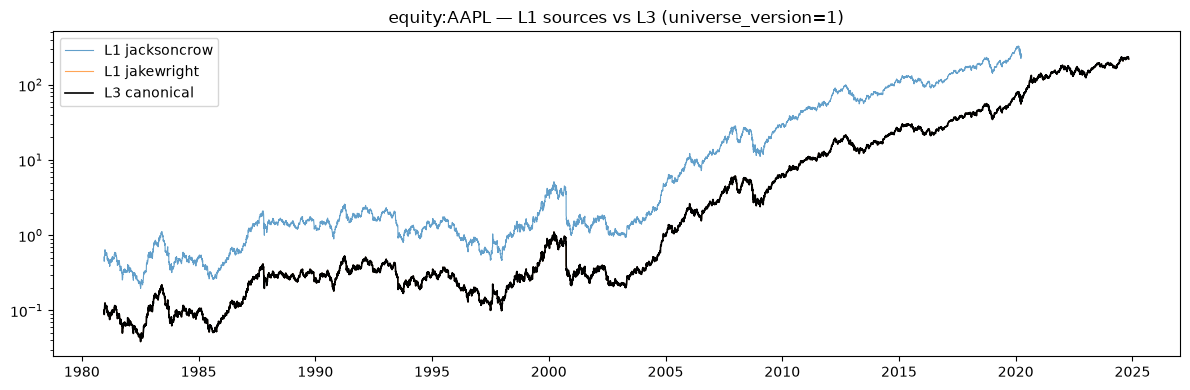

primary segments:


,series_id,source,source_symbol,valid_from,valid_to,role,universe_version
0,equity:AAPL,jakewright,AAPL,1980-12-12,2024-11-04,primary,1


In [8]:
sid = "equity:AAPL"
raw = l1_for_series(sid)
can = canonical[canonical["series_id"] == sid]

fig, ax = plt.subplots(figsize=(12, 4))
for src, g in raw.groupby("source"):
    ax.plot(g["ts"], g["close"], lw=0.8, alpha=0.7, label=f"L1 {src}")
ax.plot(can["ts"], can["close"], lw=1.2, color="black", label="L3 canonical")
ax.set_yscale("log")
ax.set_title(f"{sid} — L1 sources vs L3 (universe_version={UNIVERSE_VERSION})")
ax.legend()
plt.tight_layout()
plt.show()

print("primary segments:")
display(stitch_segments[(stitch_segments["series_id"] == sid) & (stitch_segments["role"] == "primary")])

## Stitch quality gallery

Curated examples: best → worse quality using rollups from `quality_flags`.
For each series: L1 sources (colored) + L3 canonical (black) + segment table + quality counts.


In [ ]:
# score: fewer date gaps + disagreements = better
roll = (
    quality_flags.groupby(["series_id", "level"]).size().unstack(fill_value=0)
    .reindex(columns=["date", "disagreement", "field", "suspicious", "series"], fill_value=0)
)
roll["score"] = roll["date"] + roll["disagreement"] + 5 * roll["suspicious"]
roll = roll.join(series_meta.set_index("series_id")[["canonical_symbol", "asset_class", "calendar_id"]])
roll = roll.sort_values("score")
print("quality rollup (lower score = cleaner):")
display(roll)

# pick gallery: best equity, worst equity (by score), SPY if present, DGS10 macro
equity = roll[roll["asset_class"].isin(["equity", "etf"])]
picks = []
if len(equity):
    picks.append(equity.index[0])   # best
    picks.append(equity.index[-1])  # worst
for sid in ["etf:SPY", "equity:SPY", "macro:DGS10"]:
    if sid in roll.index and sid not in picks:
        picks.append(sid)
picks = list(dict.fromkeys(picks))[:4]
print("gallery:", picks)

src_colors = {
    "jakewright": "#1f77b4",
    "jacksoncrow": "#ff7f0e",
    "stooq": "#2ca02c",
    "yfinance": "#d62728",
    "fred": "#9467bd",
}

n = len(picks)
fig, axes = plt.subplots(n, 1, figsize=(12, 3.2 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, sid in zip(axes, picks):
    raw = l1_for_series(sid)
    can = canonical[canonical["series_id"] == sid]
    r = roll.loc[sid]
    for src, g in raw.groupby("source"):
        ax.plot(g["ts"], g["close"], lw=0.8, alpha=0.65, color=src_colors.get(src, "gray"), label=f"L1 {src}")
    if len(can):
        ax.plot(can["ts"], can["close"], lw=1.3, color="black", label="L3")
    ax.set_yscale("log")
    ax.set_title(
        f"{sid} ({r['canonical_symbol']})  score={int(r['score'])}  "
        f"gaps={int(r['date'])}  disagree={int(r['disagreement'])}  suspicious={int(r['suspicious'])}"
    )
    ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

print("primary segments for gallery:")
display(
    stitch_segments[stitch_segments["series_id"].isin(picks) & (stitch_segments["role"] == "primary")]
    .sort_values(["series_id", "valid_from"])
)


## FRED production path

1. **ALFRED as-of** — same observation date, different `realtime_end` → revision leakage check  
2. **v2 release bulk** — seed whole releases (H.15 = `release_id=18`) instead of N v1 calls

In [12]:
api_key = os.environ["FRED_API_KEY"]


def fred_v1(path, **params):
    r = requests.get(
        f"https://api.stlouisfed.org/fred/{path}",
        params={**params, "api_key": api_key, "file_type": "json"},
        timeout=120,
    )
    r.raise_for_status()
    return r.json()


def fred_v2(path, **params):
    # v2 uses Bearer header, not ?api_key= (v1 query param → 401 on v2)
    r = requests.get(
        f"https://api.stlouisfed.org/fred/v2/{path}",
        params=params,
        headers={"Authorization": f"Bearer {api_key}"},
        timeout=180,
    )
    r.raise_for_status()
    return r.json()


# --- ALFRED: CPIAUCSL value for 2020-01-01 as known on 2020-02-15 vs today ---
obs_date = "2020-01-01"
asof = "2020-02-15"

alfred = pd.DataFrame(fred_v1(
    "series/observations",
    series_id="CPIAUCSL",
    observation_start=obs_date,
    observation_end=obs_date,
    realtime_start=asof,
    realtime_end=asof,
)["observations"])

fred_today = pd.DataFrame(fred_v1(
    "series/observations",
    series_id="CPIAUCSL",
    observation_start=obs_date,
    observation_end=obs_date,
)["observations"])

leak_cmp = pd.DataFrame([
    {
        "mode": "ALFRED",
        "observation_date": obs_date,
        "realtime_end": asof,
        "value": alfred.iloc[0]["value"],
        "extras_hint": {"realtime_start": asof, "realtime_end": asof},
    },
    {
        "mode": "FRED_default",
        "observation_date": obs_date,
        "realtime_end": "today",
        "value": fred_today.iloc[0]["value"],
        "extras_hint": {"realtime_end": "today_default"},
    },
])
print("CPIAUCSL revision / leakage check:")
display(leak_cmp)
print("same value?", leak_cmp.loc[0, "value"] == leak_cmp.loc[1, "value"])

CPIAUCSL revision / leakage check:


,mode,observation_date,realtime_end,value,extras_hint
0,ALFRED,2020-01-01,2020-02-15,258.820,"{'realtime_start': '2020-02-15', 'realtime_end..."
1,FRED_default,2020-01-01,today,259.127,{'realtime_end': 'today_default'}


same value? False


In [13]:
# --- v2 bulk: H.15 Selected Interest Rates (release_id=18), first page only ---
bulk = fred_v2("release/observations", release_id=18, format="json", limit=5000)

series_list = bulk.get("series", [])
print(f"release={bulk.get('release', {}).get('name')}  series_in_page={len(series_list)}  has_more={bulk.get('has_more')}")

rows = []
for s in series_list[:5]:  # sample map → L1-shaped rows
    for o in s.get("observations", [])[-3:]:
        rows.append({
            "source": "fred",
            "source_symbol": s["series_id"],
            "series_type": "macro",
            "ts": o["date"],
            "close": None if o["value"] == "." else float(o["value"]),
            "extras": json.dumps({
                "release_id": 18,
                "title": s.get("title"),
                "frequency": s.get("frequency"),
                "ingest": "fred_v2_release_observations",
            }),
        })

v2_sample = pd.DataFrame(rows)
display(v2_sample)
print("seed path: page with next_cursor until has_more=false → append L1 (source=fred)")

release=H.15 Selected Interest Rates  series_in_page=10  has_more=True


,source,source_symbol,series_type,ts,close,extras
0,fred,CD1M,macro,2013-04-01,0.18,"{""release_id"": 18, ""title"": ""Average Rate on 1..."
1,fred,CD1M,macro,2013-05-01,0.17,"{""release_id"": 18, ""title"": ""Average Rate on 1..."
2,fred,CD1M,macro,2013-06-01,0.16,"{""release_id"": 18, ""title"": ""Average Rate on 1..."
3,fred,CD3M,macro,2013-04-01,0.20,"{""release_id"": 18, ""title"": ""Average Rate on 3..."
4,fred,CD3M,macro,2013-05-01,0.20,"{""release_id"": 18, ""title"": ""Average Rate on 3..."
5,fred,CD3M,macro,2013-06-01,0.19,"{""release_id"": 18, ""title"": ""Average Rate on 3..."
6,fred,CD6M,macro,2013-04-01,0.26,"{""release_id"": 18, ""title"": ""Average Rate on 6..."
7,fred,CD6M,macro,2013-05-01,0.26,"{""release_id"": 18, ""title"": ""Average Rate on 6..."
8,fred,CD6M,macro,2013-06-01,0.26,"{""release_id"": 18, ""title"": ""Average Rate on 6..."
9,fred,CPF1M,macro,2026-05-01,3.66,"{""release_id"": 18, ""title"": ""30-Day AA Financi..."


seed path: page with next_cursor until has_more=false → append L1 (source=fred)
